## `Task` Do feature selection as per metods taught is session 54 on SECOM dataset.

Dataset Link : https://archive.ics.uci.edu/ml/datasets/SECOM

Drive Link : https://docs.google.com/spreadsheets/d/1dFCe1zgokabsiEr6BbWmMJtiMefkrChpJWLiG_0dDkk/edit?usp=share_link

In [7]:
# Write your Code here
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # to standarize the features
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , accuracy_score # since classification problem
from sklearn.feature_selection import VarianceThreshold


In [8]:
# Import raw data and get info
data = pd.read_csv("uci-secom - uci-secom.csv")

print(data.head(2))


                  Time        0        1          2          3       4      5  \
0  2008-07-19 11:55:00  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   
1  2008-07-19 12:32:00  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0   

          6       7       8  ...       581     582     583     584     585  \
0   97.6133  0.1242  1.5005  ...       NaN  0.5005  0.0118  0.0035  2.3630   
1  102.3433  0.1247  1.4966  ...  208.2045  0.5019  0.0223  0.0055  4.4447   

      586     587    588       589  Pass/Fail  
0     NaN     NaN    NaN       NaN         -1  
1  0.0096  0.0201  0.006  208.2045         -1  

[2 rows x 592 columns]


In [9]:

# Separate immediately
time_col = data['Time']                          # save if needed for time-series later
X = data.drop(columns=['Time', 'Pass/Fail'])     # 590 feature columns
y = data['Pass/Fail']

print(X.shape)   # (1567, 590)

(1567, 590)


**We got 592 Columns including Time and An Output Column**

In [10]:
# How to check which column has string dtype
X.dtypes =='str' # Okay so Time Column is Actually string type Alright 

0      False
1      False
2      False
3      False
4      False
       ...  
585    False
586    False
587    False
588    False
589    False
Length: 590, dtype: bool

**Plan Of Action - We will make a df named X and remove Time and Pass/Fail Column from it**                                                        
**Also we will make df named "y" which contains only Pass/Fail Column**

In [11]:
# Let us Check columns which are completely null
for i in X.columns:
    if X[i].isna().sum() == 1567:
        print(X[i])

In [12]:

print(X.shape)          # (1567, 591)
print(X.isnull().sum().sum())   # total missing values

# Percentage of nulls per feature
null_pct = X.isnull().mean() * 100
print(null_pct.describe())

(1567, 590)
41951
count    590.000000
mean       4.537549
std       15.433986
min        0.000000
25%        0.127632
50%        0.382897
75%        0.574346
max       91.193363
dtype: float64


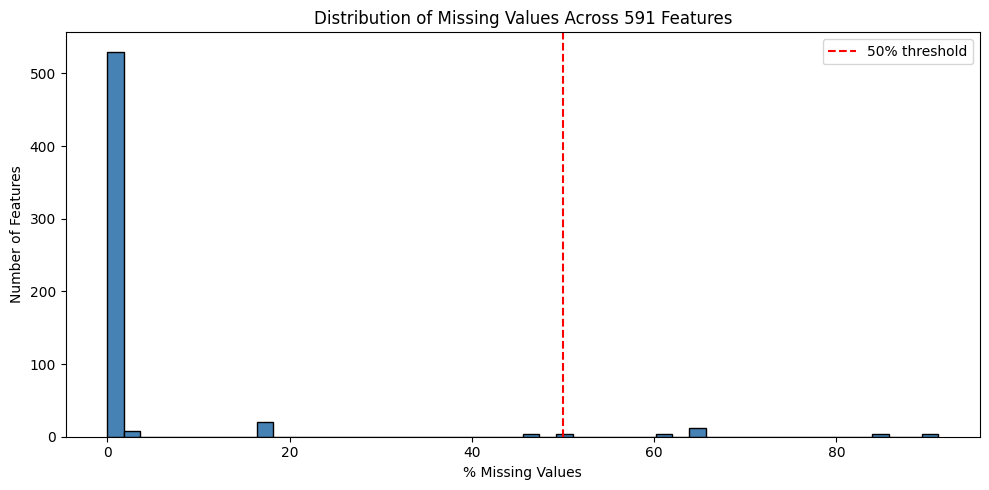

Features with 0% null      : 52
Features with 0–10% null   : 486
Features with 10–50% null  : 24
Features with >50% null    : 28
Features with >90% null    : 4


In [13]:
# Distribution of null % across features
plt.figure(figsize=(10, 5))
plt.hist(null_pct, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("% Missing Values")
plt.ylabel("Number of Features")
plt.title("Distribution of Missing Values Across 591 Features")
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

# How many features fall into each bucket?
print("Features with 0% null      :", (null_pct == 0).sum())
print("Features with 0–10% null   :", ((null_pct > 0) & (null_pct <= 10)).sum())
print("Features with 10–50% null  :", ((null_pct > 10) & (null_pct <= 50)).sum())
print("Features with >50% null    :", (null_pct > 50).sum())
print("Features with >90% null    :", (null_pct > 90).sum())

In [14]:
null_pct.sort_values(ascending=False)

292    91.193363
293    91.193363
158    91.193363
157    91.193363
492    85.577537
         ...    
523     0.000000
522     0.000000
521     0.000000
520     0.000000
120     0.000000
Length: 590, dtype: float64

In [15]:
# Let us drop all features having Null percentage more than 50
threshold = 50
cols_to_drop = null_pct[null_pct>threshold].index.to_list() # These columns we will drop

In [16]:
print(f"Features before Dropping -> {X.shape[1]}")
X = X.drop(columns=cols_to_drop)

print(f"Features After Dropping -> {X.shape[1]}")

Features before Dropping -> 590
Features After Dropping -> 562


**Why this is justified: A feature that is missing for more than half your samples cannot be reliably imputed — any value you fill in is largely fabricated. Such features also tend to contribute noise, not signal, in downstream models.**

### ***Now We use Variance Threshold***

`This will drop all the columns which are near Zero or Zero, since they add No value for our Model`

In [17]:
# fisrtly remove nulls by putting median values to check the variance properly
  
X_filled_temp = X.fillna(X.median()) # we will not use this for modelling 

# Let us use Variance Threshold now

var_sel = VarianceThreshold(threshold=0.01)
var_sel.fit(X_filled_temp) #this will fit and check for all the features 

low_var_mask = var_sel.get_support() #check for all the features above and below the threshold value (boolean data)

print(f"Before removing near-zero variance features: {X.shape[1]}")
X = X.loc[:,low_var_mask]

print(f"After removing near-zero variance features: {X.shape[1]}")



Before removing near-zero variance features: 562
After removing near-zero variance features: 297


In [18]:
# 80-20 chronological split
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"X_Train size : {X_train.shape} samples")
print(f"X_Test size  : {X_test.shape} samples")
print(f"y_train size : {y_train.shape} samples")
print(f"y_test size  : {y_test.shape} samples")


X_Train size : (1253, 297) samples
X_Test size  : (314, 297) samples
y_train size : (1253,) samples
y_test size  : (314,) samples


In [19]:
# We will use SimpleInputer to fit transform Training data with from Nulls to Median of each feature and then Transform it into Test data
# This will avoid Data Leakage

from sklearn.impute import SimpleImputer
# Fit imputer on train, transform both
imputer = SimpleImputer(strategy='median') # this will Replace NULLS with Median values of each column

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns) # transform back to Dataframe

X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # transform only, NOT fit_transform


**Now Our Data Has No Nulls and Features Reduced from 591 to Just 297**

In [20]:
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


### ***Scaling the Features***

In [21]:
scal = StandardScaler()
X_train = pd.DataFrame(scal.fit_transform(X_train) , columns = X_train.columns)
X_test = pd.DataFrame(scal.transform(X_test) ,columns =  X_test.columns)

In [22]:
# Let us Display the DataFrame
print(X_train.head())

          0         1         2         3         4         6        12  \
0  0.240152  0.834595 -0.401996  0.057046  0.165035 -0.717804  0.717005   
1  1.179897 -0.365215  0.961668  0.189218 -1.227711  0.253680  0.145134   
2 -1.184608  0.785321 -0.444233  0.778839  0.558614 -1.154355  0.589583   
3 -0.371515 -0.186081 -0.041026 -1.204267  0.060605  0.642561  0.538307   
4  0.259136  0.092694  1.055727 -0.155816  0.619487 -0.146128  0.566770   

         14        15        16  ...       569       570       571       572  \
0 -0.288540  0.121427  0.047478  ... -0.309902  0.188675 -0.105703 -0.206826   
1  0.498910  0.114112 -0.244689  ... -0.309902  0.249289  1.173639 -0.246705   
2  0.270052  0.219996 -0.224363  ...  5.205551  0.249710 -0.431296 -0.177081   
3  0.302101  0.519589 -0.083389  ...  0.497317  0.018129 -0.447178 -0.201825   
4  0.646194  0.428513  0.157646  ... -0.309902  0.093341 -0.438443 -0.208405   

        573       574       576       577        585       589  
0 -

|Remove null-heavy columns|                                                                                                                 
               ↓                                                                                                                                       
|Variance Threshold  ← catches truly flat/dead features on raw scale|                                                                  
     ↓                                                                                                                                               
|Train/Test split|                                                                                                                              
        ↓                                                                                                                                       
|StandardScaler|                                                                                                                                
        ↓                                                                                                                               
|Correlation filter, Mutual Information, L1, etc.|                                                                              

### ***Removing Duplicate Columns***

In [23]:
def get_duplicate_columns(df):
    
    duplicate_columns = {}
    seen_columns = {}

    for column in df.columns:
        current_column = df[column]

        # Convert column data to bytes
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns


In [24]:
dup_cols = get_duplicate_columns(X_train)

In [25]:
print(dup_cols)

{'74': ['209', '347', '478']}


In [26]:
# Dropping these cols from both Training and Testing Data
print(f"Before removing near-zero variance features: {X_train.shape[1]}")

X_train = X_train.drop(['209', '347', '478'],axis=1)
X_test = X_test.drop(['209', '347', '478'],axis=1)

print(f"After removing near-zero variance features: {X_train.shape[1]}")

Before removing near-zero variance features: 297
After removing near-zero variance features: 294


### ***Correlation Method***

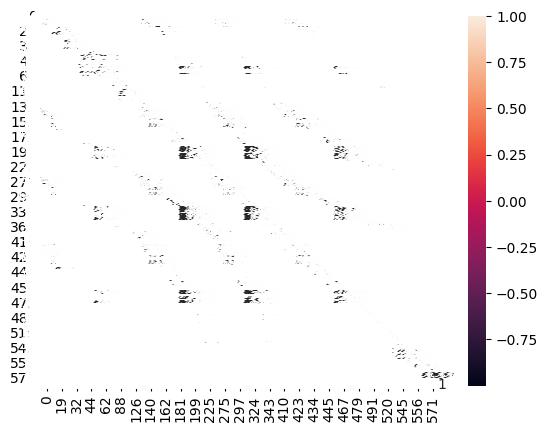

In [28]:
sns.heatmap(X_train.corr() , annot=True)
plt.show()

In [29]:
df_corr = X_train.corr()

In [ ]:
cols_to_drop = []
for i in range(X_train.shape[1]):
    for j in range(i+1 , X_train.shape[1]): # Makes an upper triangle and checking feature vs feature 
        if df_corr.iloc[i,j] > 0.95: # if correlation > 0.95 then only one column is necessary for our model
            cols_to_drop.append(j)
print(len(cols_to_drop))

155


In [34]:
cols_to_drop = list(set(cols_to_drop))
print(cols_to_drop)

[18, 67, 79, 82, 83, 91, 115, 123, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 161, 162, 163, 164, 165, 166, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 180, 186, 188, 189, 191, 192, 198, 199, 200, 201, 204, 205, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 220, 222, 223, 228, 230, 231, 241, 245, 247, 255, 257, 260, 262, 263, 271, 272, 273, 275, 276, 278, 282, 283, 289, 290, 291]


In [ ]:
print(type(cols_to_drop[2]))
print(cols_to_drop[:5]) # This shows that cols to drop is int values but our indices are string type
print(X_train.columns[:5])

<class 'int'>
[18, 67, 79, 82, 83]
Index(['0', '1', '2', '3', '4'], dtype='str')


In [ ]:
cols_to_drop_names = X_train.columns[cols_to_drop].to_list() # This will use fancy indexing to get the actual columns and convert to list

In [40]:
print(f"Before removing near-zero variance features: {X_train.shape[1]}")

X_train = X_train.drop(cols_to_drop_names ,axis=1)
X_test = X_test.drop(cols_to_drop_names ,axis=1)

print(f"AFter removing near-zero variance features: {X_train.shape[1]}")

Before removing near-zero variance features: 294
AFter removing near-zero variance features: 195


### ***We are left with 195 columns ONLY***

**USING ANOVA TO REMOVE COLUMNS FURTHER**
`ANOVA checks the significance of Numeric Feature with Classfication Output`

In [42]:
from sklearn.feature_selection import f_classif, SelectKBest
sel = SelectKBest(f_classif , k=100).fit(X_train , y_train)

# ------- Transform Now ------------
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1253, 100)
(314, 100)


### ***So we finally Reduced Our columns form 590 to just 100***

### Let us Now fit the Model and check the Accuracy Score

In [43]:
lr = LogisticRegression()

model = lr.fit(X_train , y_train) # Finally fit the Logistic Regression Model

y_pred = model.predict(X_test) # Getting the predicted values of Test data

# Checking the Accuracy Score

acc_score = accuracy_score(y_test , y_pred)

print(f"Accuracy -> {acc_score}")


Accuracy -> 0.9363057324840764


### ***Using Mutual Info For further Reduction Though We will make a new dataset so will can revert back***

In [51]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for i in [90,80,70,60,50,40,30,2]:
    sel = SelectKBest(mutual_info_classif , k = i)
    X_red = sel.fit_transform(X_train, y_train)

    X_train_new = sel.transform(X_train)
    X_test_new = sel.transform(X_test)
    
# ---------- Fitting the model also -------------------- 
    lr = LogisticRegression()

    model = lr.fit(X_train_new , y_train) # Finally fit the Logistic Regression Model

    y_pred = model.predict(X_test_new) # Getting the predicted values of Test data

    # Checking the Accuracy Score

    acc_score = accuracy_score(y_test , y_pred)

    print(f"Accuracy when cols reduced to = {i}-> {acc_score}")


    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test_new)[:, 1]))


Accuracy when cols reduced to = 90-> 0.945859872611465
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.95       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.95      0.92       314

Confusion Matrix:
 [[297   0]
 [ 17   0]]
ROC-AUC: 0.6632996632996633


c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy when cols reduced to = 80-> 0.9426751592356688
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.94       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.94      0.92       314

Confusion Matrix:
 [[296   1]
 [ 17   0]]
ROC-AUC: 0.6015052485640722
Accuracy when cols reduced to = 70-> 0.945859872611465
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.95       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.95      0.92       314

Confusion Matrix:
 [[297   0]
 [ 17   0]]
ROC-AUC: 0.6114081996434938


c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy when cols reduced to = 60-> 0.945859872611465
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.95       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.95      0.92       314

Confusion Matrix:
 [[297   0]
 [ 17   0]]
ROC-AUC: 0.6769657357892651


...

Accuracy when cols reduced to = 40-> 0.945859872611465
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.95       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.95      0.92       314

Confusion Matrix:
 [[297   0]
 [ 17   0]]
ROC-AUC: 0.6516141810259458


c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy when cols reduced to = 30-> 0.945859872611465
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.95       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.95      0.92       314

Confusion Matrix:
 [[297   0]
 [ 17   0]]
ROC-AUC: 0.6385422856011091


c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy when cols reduced to = 2-> 0.9426751592356688
              precision    recall  f1-score   support

          -1       0.95      1.00      0.97       297
           1       0.00      0.00      0.00        17

    accuracy                           0.94       314
   macro avg       0.47      0.50      0.49       314
weighted avg       0.89      0.94      0.92       314

Confusion Matrix:
 [[296   1]
 [ 17   0]]
ROC-AUC: 0.5607050901168548


### ***So we get the best accuracy at***

### `Solution`

In [ ]:
import pandas as pd

data = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQtBXo5cBnDsM2fmfHPm6u72KGUS5FjPHNGMxOfYjA9-CAhmnRpwkIw_rOR3sANJIToiUU__6fbBvig/pub?gid=572763137&single=true&output=csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [ ]:
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
